In [9]:
import h5py

filepath = r"data\smap\SMAP_L3_SM_P_E_20260314_R19240_001.h5"

with h5py.File(filepath, "r") as f:
    def print_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name}  shape={obj.shape}  dtype={obj.dtype}")
    f.visititems(print_structure)

Soil_Moisture_Retrieval_Data_AM/EASE_column_index  shape=(1624, 3856)  dtype=uint16
Soil_Moisture_Retrieval_Data_AM/EASE_row_index  shape=(1624, 3856)  dtype=uint16
Soil_Moisture_Retrieval_Data_AM/albedo  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrieval_Data_AM/albedo_scah  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrieval_Data_AM/albedo_scav  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrieval_Data_AM/boresight_incidence  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrieval_Data_AM/bulk_density  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrieval_Data_AM/clay_fraction  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrieval_Data_AM/freeze_thaw_fraction  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrieval_Data_AM/grid_surface_status  shape=(1624, 3856)  dtype=uint16
Soil_Moisture_Retrieval_Data_AM/latitude  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrieval_Data_AM/latitude_centroid  shape=(1624, 3856)  dtype=float32
Soil_Moisture_Retrie

In [10]:
import h5py
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
from rasterio.mask import mask
import matplotlib.pyplot as plt

filepath = r"data\smap\SMAP_L3_SM_P_E_20260314_R19240_001.h5"

with h5py.File(filepath, "r") as f:
    sm = f["Soil_Moisture_Retrieval_Data_AM/soil_moisture"][:]
    lat = f["Soil_Moisture_Retrieval_Data_AM/latitude"][:]
    lon = f["Soil_Moisture_Retrieval_Data_AM/longitude"][:]

# Replace fill values with NaN
sm = sm.astype(np.float32)
sm[sm == -9999.0] = np.nan

print(f"Soil moisture shape: {sm.shape}")
print(f"Lat range: {np.nanmin(lat):.2f} to {np.nanmax(lat):.2f}")
print(f"Lon range: {np.nanmin(lon):.2f} to {np.nanmax(lon):.2f}")
print(f"SM range: {np.nanmin(sm):.4f} to {np.nanmax(sm):.4f}")

Soil moisture shape: (1624, 3856)
Lat range: -9999.00 to 84.66
Lon range: -9999.00 to 179.95
SM range: 0.0200 to 0.8325


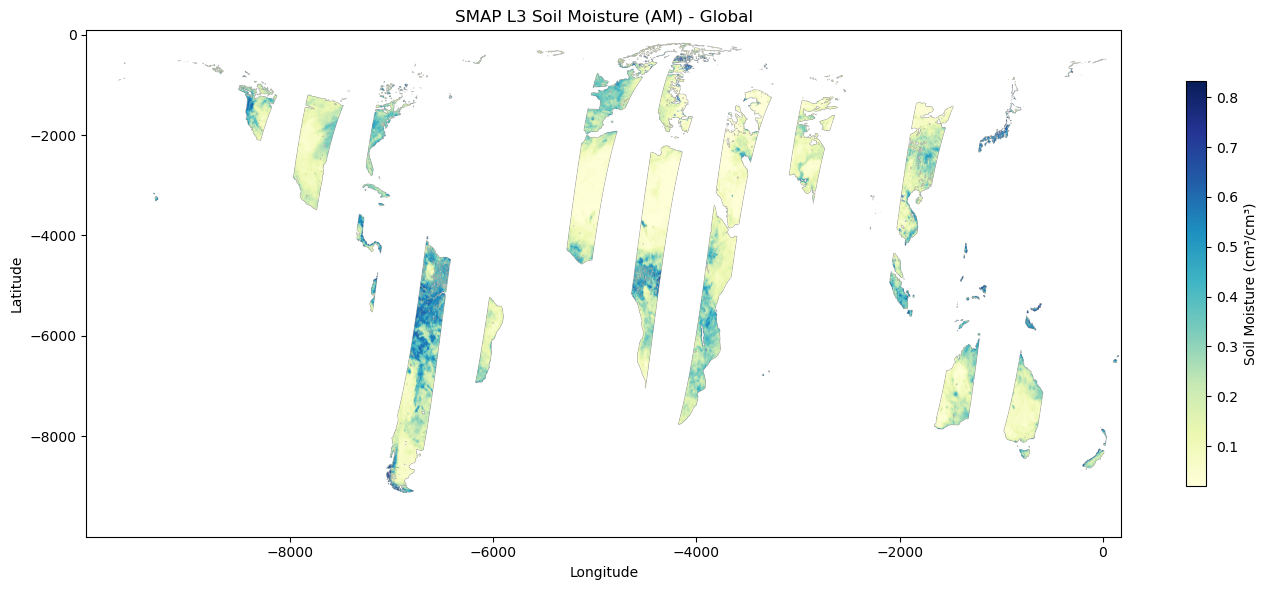

In [11]:
# Visualize the global soil moisture dataset
lat_min, lat_max = float(np.nanmin(lat)), float(np.nanmax(lat))
lon_min, lon_max = float(np.nanmin(lon)), float(np.nanmax(lon))

fig, ax = plt.subplots(figsize=(14, 6))
img = ax.imshow(sm, cmap="YlGnBu", extent=[lon_min, lon_max, lat_min, lat_max], aspect="auto")
ax.set_title("SMAP L3 Soil Moisture (AM) - Global")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(img, ax=ax, label="Soil Moisture (cm³/cm³)", shrink=0.8)
plt.tight_layout()
plt.show()

In [12]:
# Write soil moisture as a GeoTIFF using lat/lon bounds from the file
lat_min, lat_max = float(np.nanmin(lat)), float(np.nanmax(lat))
lon_min, lon_max = float(np.nanmin(lon)), float(np.nanmax(lon))
nrows, ncols = sm.shape

transform = from_bounds(lon_min, lat_min, lon_max, lat_max, ncols, nrows)

temp_tif = "data/smap/smap_sm_am.tif"
with rasterio.open(
    temp_tif, "w", driver="GTiff",
    height=nrows, width=ncols, count=1,
    dtype=sm.dtype, crs="EPSG:4326",
    transform=transform, nodata=np.nan,
) as dst:
    dst.write(sm, 1)

print(f"Saved raster to {temp_tif}")

# Load Azuay boundary and clip
azuay = gpd.read_file(r"data\adm_ecu\azuay_boundary.shp").to_crs("EPSG:4326")

with rasterio.open(temp_tif) as src:
    clipped, clipped_transform = mask(src, azuay.geometry, crop=True, nodata=np.nan)
    clipped_meta = src.meta.copy()

clipped_meta.update({
    "height": clipped.shape[1],
    "width": clipped.shape[2],
    "transform": clipped_transform,
})

out_tif = "data/smap/smap_sm_am_azuay.tif"
with rasterio.open(out_tif, "w", **clipped_meta) as dst:
    dst.write(clipped)

print(f"Clipped raster saved to {out_tif}")
print(f"Clipped shape: {clipped.shape}")

Saved raster to data/smap/smap_sm_am.tif
Clipped raster saved to data/smap/smap_sm_am_azuay.tif
Clipped shape: (1, 1, 2)


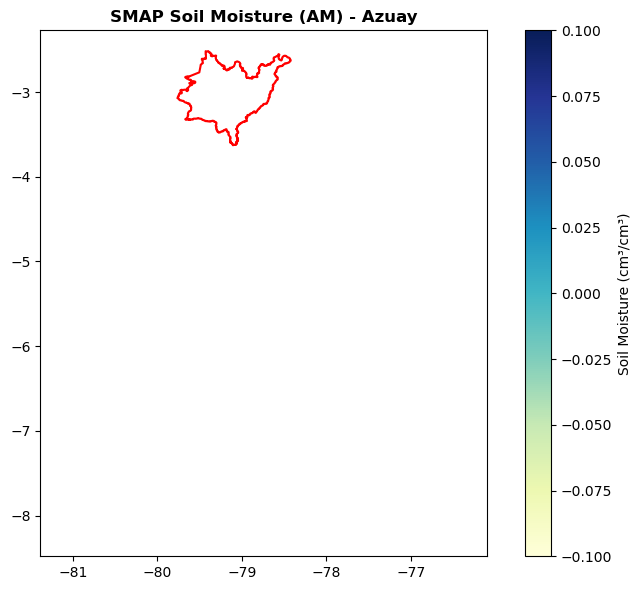

In [13]:
# Plot the clipped soil moisture over Azuay
fig, ax = plt.subplots(figsize=(8, 6))

from rasterio.plot import show
with rasterio.open(out_tif) as src:
    show(src, ax=ax, cmap="YlGnBu", title="SMAP Soil Moisture (AM) - Azuay")
azuay.boundary.plot(ax=ax, edgecolor="red", linewidth=1.5)

plt.colorbar(ax.images[0], ax=ax, label="Soil Moisture (cm³/cm³)")
plt.tight_layout()
plt.show()

In [2]:
import geopandas as gpd

#sites_path = r"C:\HyGalapgos\Model\Outputs\sites_poly1.shp"
sites_path = r"C:\SolarSuitability\Outputs\sites_0805.shp"

areas_protegidas = r"C:\HyGalapgos\areas_protegidas\SNAP_MAATE\SNAP_Galapagos_MAATE_05_2023_50K_15S.shp"

sites = gpd.read_file(sites_path)

# Reproject to UTM 15S for metric area calculation
sites_utm = sites.to_crs(epsg=32715)

sites_utm["area_m2"] = sites_utm.geometry.area
sites_utm["area_ha"] = sites_utm["area_m2"] / 10_000
sites_utm["area_km2"] = sites_utm["area_m2"] / 1_000_000

total_m2  = sites_utm["area_m2"].sum()
total_ha  = sites_utm["area_ha"].sum()
total_km2 = sites_utm["area_km2"].sum()

print(f"Number of sites : {len(sites_utm)}")
print(f"Total area      : {total_m2:,.2f} m²")
print(f"                : {total_ha:,.4f} ha")
print(f"                : {total_km2:,.4f} km²")
print(f"\nPer-site area (ha):")
print(sites_utm["area_ha"].describe().round(4))

Number of sites : 230
Total area      : 1,101,822,076.17 m²
                : 110,182.2076 ha
                : 1,101.8221 km²

Per-site area (ha):
count     230.0000
mean      479.0531
std      1055.2109
min        88.7135
25%        88.7135
50%        88.7135
75%       266.1406
max      7895.5044
Name: area_ha, dtype: float64


In [3]:

import geopandas as gpd
import pandas as pd

# --- File paths ---
solar_path    = r"C:\SolarSuitability\Outputs\sites_poly.shp"
eolic_path    = r"C:\HyGalapgos\Model\Outputs\sites_poly1.shp"
protected_path = r"C:\HyGalapgos\areas_protegidas\SNAP_MAATE\SNAP_Galapagos_MAATE_05_2023_50K_15S.shp"

# --- Load and reproject to UTM 15S (EPSG:32715) for metric area ---
crs_metric = "EPSG:32715"
solar     = gpd.read_file(solar_path).to_crs(crs_metric)
eolic     = gpd.read_file(eolic_path).to_crs(crs_metric)
protected = gpd.read_file(protected_path).to_crs(crs_metric)

# --- Helper: area stats (m², ha, km²) ---
def area_stats(gdf, label):
    total_m2  = gdf.geometry.area.sum()
    total_ha  = total_m2 / 10_000
    total_km2 = total_m2 / 1_000_000
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  N sites   : {len(gdf)}")
    print(f"  Total area: {total_m2:>15,.2f} m²")
    print(f"             {total_ha:>15,.4f} ha")
    print(f"             {total_km2:>15,.4f} km²")
    return total_ha

# --- Helper: split by protected areas ---
def split_by_protected(gdf, protected, label):
    # Union all protected areas into a single geometry
    protected_union = protected.union_all()

    # Inside protected areas
    inside = gdf.copy()
    inside.geometry = gdf.geometry.intersection(protected_union)
    inside = inside[~inside.geometry.is_empty]

    # Outside protected areas
    outside = gdf.copy()
    outside.geometry = gdf.geometry.difference(protected_union)
    outside = outside[~outside.geometry.is_empty]

    inside_ha  = inside.geometry.area.sum() / 10_000
    outside_ha = outside.geometry.area.sum() / 10_000
    total_ha   = inside_ha + outside_ha

    print(f"\n  {label} — breakdown vs. protected areas:")
    print(f"    Inside  protected areas : {inside_ha:>12,.4f} ha  ({inside_ha/total_ha*100:.1f}%)")
    print(f"    Outside protected areas : {outside_ha:>12,.4f} ha  ({outside_ha/total_ha*100:.1f}%)")

    return inside_ha, outside_ha

# --- Run analysis ---
print("AREA STATISTICS — SOLAR & EOLIC POTENTIAL SITES")

area_stats(solar, "Solar potential sites")
split_by_protected(solar, protected, "Solar")

area_stats(eolic, "Eolic (wind) potential sites")
split_by_protected(eolic, protected, "Eolic")

# --- Summary table ---
rows = []
for label, gdf in [("Solar", solar), ("Eolic", eolic)]:
    protected_union = protected.union_all()
    inside_ha  = gdf.geometry.intersection(protected_union).area.sum() / 10_000
    outside_ha = gdf.geometry.difference(protected_union).area.sum() / 10_000
    total_ha   = gdf.geometry.area.sum() / 10_000
    rows.append({"Dataset": label,
                 "Total (ha)": round(total_ha, 4),
                 "Inside protected (ha)": round(inside_ha, 4),
                 "Outside protected (ha)": round(outside_ha, 4),
                 "% inside": round(inside_ha / total_ha * 100, 2)})

summary = pd.DataFrame(rows)
print("\n\nSUMMARY TABLE")
print(summary.to_string(index=False))


AREA STATISTICS — SOLAR & EOLIC POTENTIAL SITES

  Solar potential sites
  N sites   : 305
  Total area:  660,028,683.31 m²
                 66,002.8683 ha
                    660.0287 km²

  Solar — breakdown vs. protected areas:
    Inside  protected areas :  61,341.9655 ha  (92.9%)
    Outside protected areas :   4,660.9028 ha  (7.1%)

  Eolic (wind) potential sites
  N sites   : 1726
  Total area:  205,620,000.00 m²
                 20,562.0000 ha
                    205.6200 km²

  Eolic — breakdown vs. protected areas:
    Inside  protected areas :  19,246.5959 ha  (93.6%)
    Outside protected areas :   1,315.4041 ha  (6.4%)


KeyboardInterrupt: 